# Trusting Code - LLM Coding and Verification Example

Here we will try to construct tuning curves and link them back to cell types and connectivity. I will build up one step at a time, using Claude Code. I have artificially broken down the steps for clarity in this tutorial, but they could be laid out in one long prompt such that the final goal is more clear to the LLM.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from pathlib import Path
import hdmf
import pynwb
# from nwbwidgets import nwb2widget # note: nwbwidgets errors on load, requires pynbw==3.0.0
from hdmf_zarr import NWBZarrIO

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;">

#### [Prompt] 

Objective:
We are trying to generate an analysis of tuning to drifting gratings and natural stimuli in optical physiology data (2-photon imaging of GCaMP6s calcium indicator signal) from the Allen Institute V1 DeepDive data set. We would like to combine this back with inferred cell types and connectivity from the EM portion of the data set.

Data formats:
- Physiology data is stored in NWB files in the data/409828_V1DD_Filtered folder
- Please consult the Functional Data Access.ipynb and data-access-tutorial-1.ipynb notebooks
- Each subfolder constitutes a recording session. Within each session are the activity traces for a number of regions of interest (roi's) corresponding to soma locations 
- Each session is organized into "Epochs" with different types of stimuli being presented. Within each epoch the stimulus table shows when particular stimulus parameters are delivered.
- Functional data are linked to the EM data through the 'roi' identifier and coregistration_1196.feather table
- Cell types should be in soma_and_cell_type_1196.feather

For the first step, let us construct an orientation tuning curve for session_name = '409828_2018-11-06_14-02-59_filtered_2026-04-09_04-59-00' 
- Pick an roi with a robust response to drifting_gratings_full or drifting_gratings_windowed for testing (tell me which roi is being used)
- Please first walk through the logic of the computation and your plan with me
- Document analysis steps with inline comments 
- Ask me about any decisions about how to handle parts of the analysis
- Plot the resulting tuning curve

Output format:
- Please write a code block in the section of this code verification Jupyter notebook after "Step 1: Compute tuning curves"




<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #DDEDE4;">

#### Its response to me

It read the model ipynbs, looked at the directory structure, then laid out a plan:

- Load the NWB file at /data/409828_V1DD_Filtered/409828_2018-11-06_14-02-59_filtered_2026-04-09_04-59-00/409828_2018-11-06_14-02-59.nwb.zarr using NWBZarrIO.

- Select a responsive ROI — iterate across planes (plane-0 through plane-5), find which dF/F columns are somas (is_soma == True), and pick one with a high mean response during drifting grating epochs relative to spontaneous. [It does not seem to implement the is_soma check in the code, probably because the data provided is "Soma-only ROIs"]

- Extract the stimulus table — filter for drifting_gratings_full (or _windowed) rows; each row has start_time, stop_time, direction, temporal_frequency, spatial_frequency.

- Compute per-trial responses — for each stimulus trial, find the dF/F timestamps within the [start_time, stop_time] window and take the mean dF/F as the trial response. This gives a vector of responses, one per trial.

- Average by direction — group trials by direction, compute mean ± SEM across repeats.

- Plot the tuning curve — polar or Cartesian plot of mean response vs. direction.

Decisions it prompted for my input on:

- Which stimulus type should we use for the tuning curve? (drifting_gratings_full (recommended) / drifting_gratings_windowed)? I chose full

- How should we handle the calcium indicator response latency (~0.5-1s lag between spiking at dF/F peak)? 
Me: Other: Choose an appropriate response window based on latency to peak of the data

- How should we handle multiple temporal/spatial frequencies in the tuning curve? (Average across all or pick preferred, I choose average across all)

- Direction tuning (0-360deg) (recommended) or orientation (0-180)? I select orientation based on biological considerations


#### Step 1: Compute tuning curves

drifting_gratings_full — 192 trials
  Directions (deg): [np.float64(0.0), np.float64(30.0), np.float64(60.0), np.float64(90.0), np.float64(120.0), np.float64(150.0), np.float64(180.0), np.float64(210.0), np.float64(240.0), np.float64(270.0), np.float64(300.0), np.float64(330.0)]
  TF (Hz):          [np.float64(1.0)]
  SF (cpd):         [np.float64(0.03999999910593033), np.float64(0.07999999821186066)]
  plane-0:   9 ROIs | best SNR = 0.19  (roi_id = 4)
  plane-1:  40 ROIs | best SNR = 1.57  (roi_id = 8)
  plane-2:  59 ROIs | best SNR = 5.82  (roi_id = 13)
  plane-3: 165 ROIs | best SNR = 7.96  (roi_id = 16)
  plane-4: 325 ROIs | best SNR = 2.22  (roi_id = 7)
  plane-5: 316 ROIs | best SNR = 6.48  (roi_id = 13)

→ Using ROI 16 (plane-3, SNR = 7.96)
PSTH peak latency : 1.26 s after onset
Response window   : [0.70 – 2.50] s relative to onset
Missing responses : 0 / 192

Orientation tuning table:
 orientation  mean_response      sem  n_trials
           0      -0.291314 0.178028        29


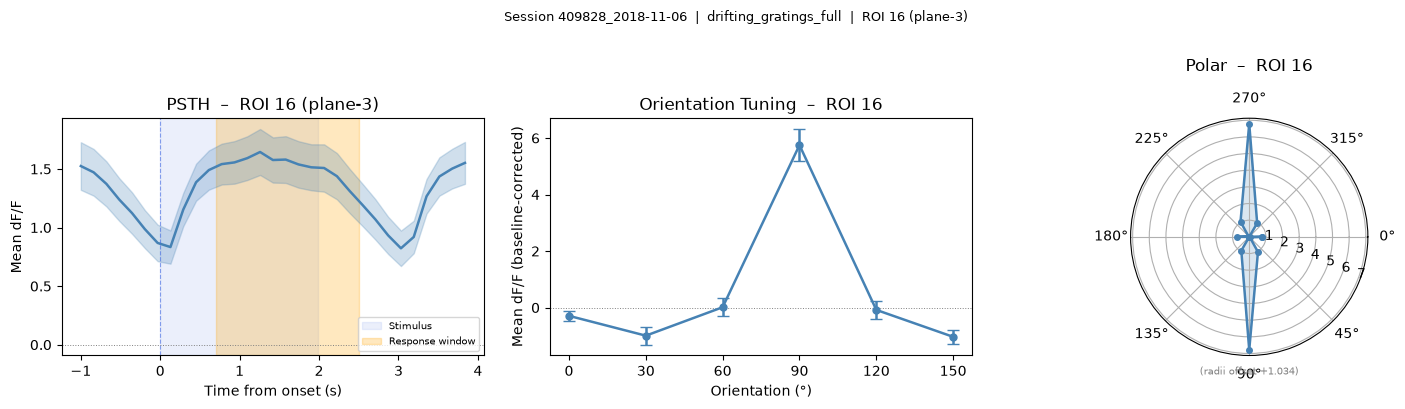

In [ ]:
# GENERATED CODE

# === Step 1: Orientation Tuning Curve ===
# Session:  409828_2018-11-06_14-02-59
# Stimulus: drifting_gratings_full
# Response: mean dF/F in a data-driven window centered on the PSTH peak, baseline-corrected
# TF / SF:  averaged across all conditions
# Output:   orientation tuning curve (direction % 180 collapses opposite directions)

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from hdmf_zarr import NWBZarrIO
from pathlib import Path

# ── 1. Load NWB file ──────────────────────────────────────────────────────────
session_name = '409828_2018-11-06_14-02-59_filtered_2026-04-09_04-59-00'
nwb_filename = '409828_2018-11-06_14-02-59.nwb.zarr'
nwb_path     = str(Path('/data/409828_V1DD_Filtered') / session_name / nwb_filename)

io      = NWBZarrIO(nwb_path, mode='r')
nwbfile = io.read()

# ── 2. Extract epoch and stimulus tables ──────────────────────────────────────
# epoch_table: one row per stimulus block (stim_name, start_time, stop_time)
# stim_table:  one row per individual trial (start_time, stop_time, direction, TF, SF, ...)
epoch_table = nwbfile.intervals['epochs'].to_dataframe()
stim_table  = nwbfile.intervals['stimulus_table'].to_dataframe()

dg_stim = stim_table[stim_table['stim_name'] == 'drifting_gratings_full'].copy()
print(f"drifting_gratings_full — {len(dg_stim)} trials")
print(f"  Directions (deg): {sorted(dg_stim['direction'].dropna().unique())}")
print(f"  TF (Hz):          {sorted(dg_stim['temporal_frequency'].dropna().unique())}")
print(f"  SF (cpd):         {sorted(dg_stim['spatial_frequency'].dropna().unique())}")

# Epoch-level time spans for ROI responsiveness scoring
dg_epochs    = epoch_table[epoch_table['stim_name'] == 'drifting_gratings_full']
spont_epochs = epoch_table[epoch_table['stim_name'] == 'spontaneous']

# ── 3. Select the most responsive soma across all imaging planes ──────────────
# SNR = mean(dF/F during grating epochs) / std(dF/F during spontaneous epochs)
# Higher SNR → more grating-driven activity relative to baseline fluctuations.
best_snr      = -np.inf
best_roi_info = None

for plane_name in [f'plane-{i}' for i in range(6)]:
    try:
        dff_obj   = nwbfile.processing[plane_name]['dff']
        ts        = dff_obj.timestamps[:]   # imaging frame timestamps (s); zero = session start
        roi_table = dff_obj.rois.to_dataframe()

        # Boolean frame masks for each condition
        grating_mask = np.zeros(len(ts), dtype=bool)
        for _, row in dg_epochs.iterrows():
            grating_mask |= (ts >= row['start_time']) & (ts <= row['stop_time'])

        spont_mask = np.zeros(len(ts), dtype=bool)
        for _, row in spont_epochs.iterrows():
            spont_mask |= (ts >= row['start_time']) & (ts <= row['stop_time'])

        # Fall back to all non-grating frames if no spontaneous epoch recorded
        if not spont_mask.any():
            spont_mask = ~grating_mask
            print(f"  {plane_name}: no spontaneous epoch — using non-grating frames as baseline")

        if not grating_mask.any():
            print(f"  {plane_name}: no grating frames — skipping")
            continue

        # Load full dF/F matrix for this plane, score ROIs, then free memory
        dff_all      = dff_obj.data[:]                 # (nframes, n_rois)
        grating_mean = dff_all[grating_mask].mean(axis=0)
        spont_std    = dff_all[spont_mask].std(axis=0)
        spont_std[spont_std < 1e-6] = 1e-6            # guard against /0
        snr          = grating_mean / spont_std
        best_idx     = int(np.argmax(snr))
        del dff_all                                    # release memory before next plane

        roi_id_best = int(roi_table.iloc[best_idx]['roi'])
        print(f"  {plane_name}: {len(roi_table):3d} ROIs | "
              f"best SNR = {snr[best_idx]:.2f}  (roi_id = {roi_id_best})")

        if snr[best_idx] > best_snr:
            best_snr      = float(snr[best_idx])
            best_roi_info = dict(
                plane      = plane_name,
                array_idx  = best_idx,
                roi_id     = roi_id_best,
                snr        = best_snr,
                timestamps = ts,
            )

    except Exception as e:
        print(f"  {plane_name}: {e}")

print(f"\n→ Using ROI {best_roi_info['roi_id']} "
      f"({best_roi_info['plane']}, SNR = {best_roi_info['snr']:.2f})")

# ── 4. Load single-ROI dF/F trace ────────────────────────────────────────────
dff_obj_sel = nwbfile.processing[best_roi_info['plane']]['dff']
roi_dff     = np.array(dff_obj_sel.data[:, best_roi_info['array_idx']])  # (nframes,)
timestamps  = best_roi_info['timestamps']

# ── 5. Build average PSTH → determine data-driven response window ─────────────
# Align every trial to its onset, interpolate to a common time grid, then average.
# The window is placed at ±0.5 s around the PSTH peak, which automatically
# absorbs the ~0.5–1 s calcium indicator lag.
stim_dur = float((dg_stim['stop_time'] - dg_stim['start_time']).median())
pre_win  = 1.0   # s of pre-stimulus context (for display and baseline)
post_win = 2.0   # s after offset to capture GCaMP decay

dt     = float(np.median(np.diff(timestamps)))         # inter-frame interval (s)
t_grid = np.arange(-pre_win, stim_dur + post_win, dt)  # common time axis

psth_matrix = np.full((len(dg_stim), len(t_grid)), np.nan)
for i, (_, row) in enumerate(dg_stim.iterrows()):
    onset  = row['start_time']
    t_rel  = timestamps - onset
    in_win = (t_rel >= -pre_win) & (t_rel <= stim_dur + post_win)
    idx    = np.where(in_win)[0]
    if len(idx) < 2:
        continue
    # Interpolate to common grid so misaligned frames can be averaged across trials
    psth_matrix[i] = np.interp(t_grid, t_rel[idx], roi_dff[idx])

mean_psth = np.nanmean(psth_matrix, axis=0)
sem_psth  = (np.nanstd(psth_matrix, axis=0)
             / np.sqrt(np.sum(~np.isnan(psth_matrix), axis=0).clip(1)))

# Locate peak within [0, stim_dur + 1 s] (the extra 1 s allows for calcium lag)
in_stim    = (t_grid >= 0) & (t_grid <= stim_dur + 1.0)
peak_lat   = float(t_grid[in_stim][np.argmax(mean_psth[in_stim])])
half_win   = 0.5
resp_start = max(0.0,            peak_lat - half_win)
resp_end   = min(stim_dur + 1.0, peak_lat + half_win)

print(f"PSTH peak latency : {peak_lat:.2f} s after onset")
print(f"Response window   : [{resp_start:.2f} – {resp_end:.2f}] s relative to onset")

# ── 6. Compute per-trial responses (window mean minus pre-stim baseline) ──────
trial_responses = []
for _, row in dg_stim.iterrows():
    onset  = row['start_time']
    t_rel  = timestamps - onset

    # 0.5 s pre-stimulus window for baseline estimate
    base_idx = np.where((t_rel >= -0.5) & (t_rel < 0.0))[0]
    baseline = float(np.nanmean(roi_dff[base_idx])) if len(base_idx) > 0 else 0.0

    resp_idx = np.where((t_rel >= resp_start) & (t_rel <= resp_end))[0]
    if len(resp_idx) == 0:
        trial_responses.append(np.nan)
    else:
        trial_responses.append(float(np.nanmean(roi_dff[resp_idx])) - baseline)

dg_stim = dg_stim.copy()
dg_stim['response'] = trial_responses
print(f"Missing responses : {dg_stim['response'].isna().sum()} / {len(dg_stim)}")

# ── 7. Orientation tuning: collapse direction → orientation (direction % 180) ─
# Gratings moving in opposite directions (e.g. 0° and 180°) share the same
# spatial orientation.  Averaging them gives orientation selectivity rather
# than direction selectivity.  All TF and SF conditions are pooled.
dg_stim = dg_stim.dropna(subset=['direction', 'response'])
dg_stim['orientation'] = (dg_stim['direction'].round().astype(int) % 180)

tuning = (
    dg_stim.groupby('orientation')['response']
    .agg(
        mean_response = 'mean',
        sem           = lambda x: x.std(ddof=1) / np.sqrt(x.count()),
        n_trials      = 'count',
    )
    .reset_index()
)
print("\nOrientation tuning table:")
print(tuning.to_string(index=False))

# ── 8. Visualize ──────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 4))

# 8a — Average PSTH with response window annotated
ax1 = fig.add_subplot(1, 3, 1)
ax1.axvspan(0,          stim_dur,  alpha=0.10, color='royalblue', label='Stimulus')
ax1.axvspan(resp_start, resp_end,  alpha=0.25, color='orange',    label='Response window')
ax1.fill_between(t_grid, mean_psth - sem_psth, mean_psth + sem_psth,
                 color='steelblue', alpha=0.25)
ax1.plot(t_grid, mean_psth, color='steelblue', lw=1.8)
ax1.axvline(0, color='royalblue', ls='--', lw=0.8, alpha=0.6)
ax1.axhline(0, color='gray',      ls=':',  lw=0.7)
ax1.set_xlabel('Time from onset (s)')
ax1.set_ylabel('Mean dF/F')
ax1.set_title(f"PSTH  –  ROI {best_roi_info['roi_id']} ({best_roi_info['plane']})")
ax1.legend(fontsize=7)

# 8b — Cartesian orientation tuning curve (mean ± SEM)
ax2 = fig.add_subplot(1, 3, 2)
oris  = tuning['orientation'].values
means = tuning['mean_response'].values
sems  = tuning['sem'].values
ax2.errorbar(oris, means, yerr=sems, fmt='o-', capsize=4,
             color='steelblue', ecolor='steelblue', lw=1.8, ms=5)
ax2.axhline(0, color='gray', ls=':', lw=0.7)
ax2.set_xticks(oris)
ax2.set_xlabel('Orientation (°)')
ax2.set_ylabel('Mean dF/F (baseline-corrected)')
ax2.set_title(f"Orientation Tuning  –  ROI {best_roi_info['roi_id']}")

# 8c — Polar orientation tuning (mirrored to full 360° circle)
# The 0–180° curve is duplicated at 180–360° to give a symmetric polar display.
ax3 = fig.add_subplot(1, 3, 3, projection='polar')
angles_h   = np.deg2rad(oris)
angles_all = np.concatenate([angles_h, angles_h + np.pi])
resp_all   = np.tile(means, 2)
loop_ang   = np.append(angles_all, angles_all[0])   # close the loop
loop_resp  = np.append(resp_all,   resp_all[0])
# Shift so all polar radii >= 0 (matplotlib polar axes require non-negative radii)
offset = max(0.0, -loop_resp.min())
ax3.plot(loop_ang, loop_resp + offset, 'o-', color='steelblue', lw=1.8, ms=4)
ax3.fill(loop_ang, loop_resp + offset, alpha=0.2, color='steelblue')
ax3.set_theta_zero_location('E')   # 0 deg points East (rightward grating)
ax3.set_theta_direction(-1)        # clockwise (standard visual field convention)
ax3.set_title(f"Polar  –  ROI {best_roi_info['roi_id']}", pad=15)
if offset > 0:
    ax3.text(0.5, -0.08, f'(radii offset +{offset:.3f})',
             transform=ax3.transAxes, ha='center', fontsize=7, color='gray')

plt.suptitle(
    f"Session 409828_2018-11-06  |  drifting_gratings_full  |  "
    f"ROI {best_roi_info['roi_id']} ({best_roi_info['plane']})",
    fontsize=9, y=1.01,
)
plt.tight_layout()
plt.show()


#### Verification

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #FFFFD8;">

First it re-imports a bunch of libraries already imported in the top block, which isn't a big deal.

To identify a unit that is most responsive to drifting_gratings_full, it uses signal-to-noise ratio (SNR) between response during grating epoch versus spontaneous epoch. It is calculated as:
```python
snr = grating_mean / spont_std
```
It also uses:
```python
# Fall back to all non-grating frames if no spontaneous epoch recorded
```

_What do you think?_



<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #FFFFD8;">

But we just needed it to select a strongly responsive cell for testing, so let's first plot the response of the selected unit (ROI 16, plane 3) during the stimulus period and see if it responds robustly and the tuning makes sense with what is shown.

We can use data_access-tutorial-1.ipynb to support us.

Let's use a slightly different data loading method just to cross-check

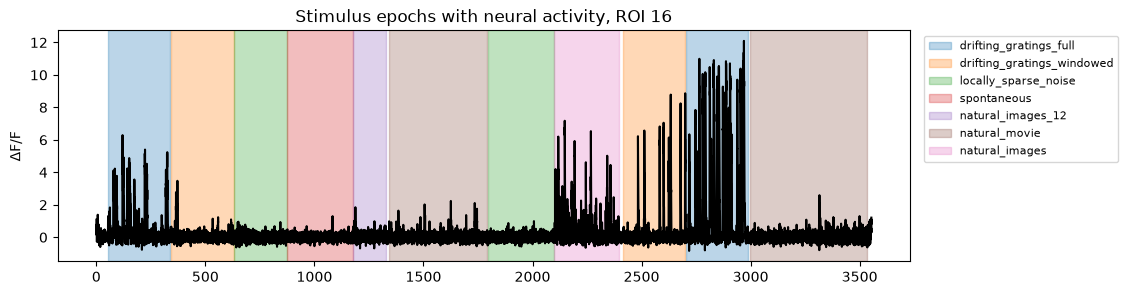

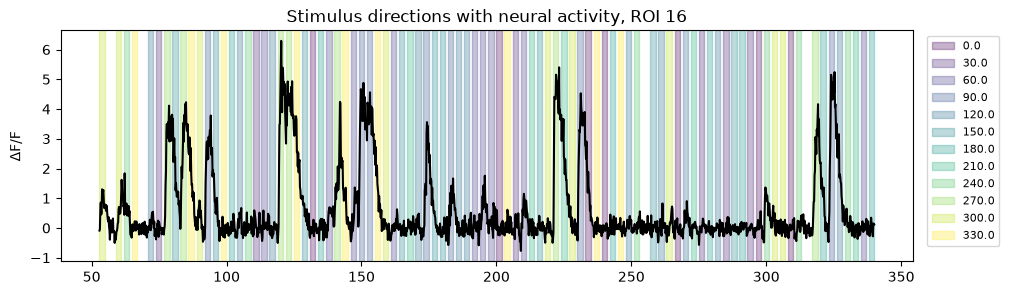

In [ ]:
import pynwb

nwb = pynwb.read_nwb(nwb_path)
dff_obj_sel = nwb.processing['plane-3']['dff']
dff = dff_obj_sel.data
roi_dff     = np.array(dff_obj_sel.data[:, 16])  # (nframes,)
ts = nwb.processing['plane-3']['dff'].timestamps[:]

ROI = 16

# Visualize epochs
epochs = nwb.intervals['epochs'].to_dataframe()
names = epochs.stim_name.unique()
colors = dict(zip(names, plt.cm.tab10.colors))

def shade_epochs(ax):
    """Shade each epoch on ax, one color per stimulus name."""
    for name in names:
        stim = epochs[epochs.stim_name == name]

        for i, (start, stop) in enumerate(zip(stim.start_time, stim.stop_time)):
            ax.axvspan(start, stop,
                       color=colors[name],
                       alpha=0.3,
                       label=name if i == 0 else None)   # label only the first
    
fig, ax = plt.subplots(1, 1, figsize=(11, 3), sharex=True)

# Plot neural activity 
ax.plot(ts, dff[:, ROI], color='black')
ax.set_ylabel(r'$\Delta$F/F')
ax.set_title(f'Stimulus epochs with neural activity, ROI {ROI}')

# Add epoch shading 
shade_epochs(ax)

# Add legend 
ax.legend(bbox_to_anchor=(1.01, 1.0), loc='upper left', fontsize=8)


# Visualize stimulus periods
stimulus_table = nwb.intervals['stimulus_table'].to_dataframe()
drifting_gratings_full_stimulus = stimulus_table[(stimulus_table.stim_name == 'drifting_gratings_full') \
                                & (stimulus_table.start_time <= epochs[epochs.stim_name == 'drifting_gratings_full'].stop_time.values[0])]
presentations = drifting_gratings_full_stimulus 
directions = sorted(presentations.direction.dropna().unique())
colors2 = dict(zip(directions, plt.colormaps['viridis'].resampled(len(directions)).colors))

def shade_stimulus_direction(ax):
    for direction in directions:
        stim = presentations[presentations.direction == direction]

        for i, (start, stop) in enumerate(zip(stim.start_time, stim.stop_time)):
            ax.axvspan(start, stop,
                       color=colors2[direction],
                       alpha=0.3,
                       label=direction if i == 0 else None)   # label only the first

# Plot neural activity 
fig, ax = plt.subplots(1, 1, figsize=(11, 3), sharex=True)

starts = epochs[epochs.stim_name == 'drifting_gratings_full'].start_time
stops = epochs[epochs.stim_name == 'drifting_gratings_full'].stop_time
inds = np.where((ts > starts[0]) & (ts < stops[0]))[0]
ts_sub = ts[inds]
dff_sub = dff[:, ROI][inds]

ax.plot(ts_sub, dff_sub, color='black')
ax.set_ylabel(r'$\Delta$F/F')
ax.set_title(f'Stimulus directions with neural activity, ROI {ROI}')  

# Add stimulus shading 
shade_stimulus_direction(ax)
# Gaps are NaNs

# Add legend 
ax.legend(bbox_to_anchor=(1.01, 1.0), loc='upper left', fontsize=8)

plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #FFFFD8;">

Indeed this ROI responds well to drifting gratings and its preferred direction seems plausibly near 90 or 270 (e.g., doesn't respond to yellow or light blue), but may be easier to see after collapsing orientations.

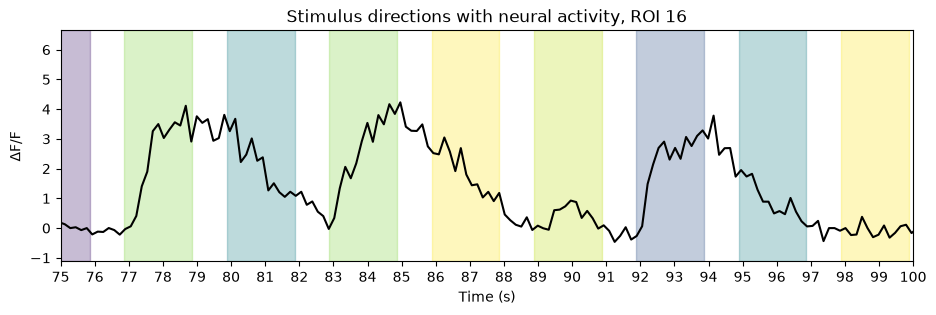

In [16]:
# Plot timecourse of individual responses - let's zoom in around 75 - 100 s

fig, ax = plt.subplots(1, 1, figsize=(11, 3), sharex=True)
ax.plot(ts_sub, dff_sub, color='black')
ax.set_ylabel(r'$\Delta$F/F')
ax.set_title(f'Stimulus directions with neural activity, ROI {ROI}') 
shade_stimulus_direction(ax)
ax.set_xlabel('Time (s)')

ax.set_xlim(75, 100)
ax.set_xticks(np.arange(75, 100 + 1, 1))

plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #FFFFD8;">

The timecourse seems reasonable as well. But is it reasonable to consider 0.5 s to 0 seconds preceding the stimulus as "baseline", as the AI code tries to do? For calcium imaging where the response is a delta or change in signal, is it necessary to baseline? Was F0 calculated session-wide or separately for every trial? Do we want to know overall signal or relative to the state immediately before that trial? But what about overall decaying signal from preceding response? Perhaps a deconvolution would be better? Could there be meaningful signal e.g., anticipation in the pre-stimulus period?

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #FFFFD8;">

_Why is it doing this?_
```python
dg_stim = dg_stim.copy()
```
AI generated code apparently will do this conservatively to prevent unintentional mutation bugs, at the cost of additional memory usage and copy time. Here, is this good practice or unnecesary, especially when dg_stim was already copied when first created? What happens if we comment that line out?

Next let's check the collapsing of stimuli across directions. _Does the code do the right computation?_
```python
dg_stim['orientation'] = (dg_stim['direction'].round().astype(int) % 180)
```

In [ ]:
# Let's write a unit test

print(dg_stim.groupby('direction')['orientation'].unique())   # Does this look right?

dir2orient = dict(zip(dg_stim['direction'], dg_stim['orientation']))   # Python will use last key-value pair for each but we just checked uniqueness above

def test_collapse_directions_to_orientations():
    dg_stim_test = pd.DataFrame({
        "direction": [0, 90, 180, 270]
    })

    expected_orientations = [0, 90, 0, 90]
    output_orientations = [dir2orient[dir] for dir in dg_stim_test["direction"]]
    print("Expected orientations:", expected_orientations)
    print("Output orientations:", output_orientations)

    assert output_orientations == expected_orientations, "Error: Orientations are not correct!"

test_collapse_directions_to_orientations()      # No error means we are good to go


direction
0.0        [0]
30.0      [30]
60.0      [60]
90.0      [90]
120.0    [120]
150.0    [150]
180.0      [0]
210.0     [30]
240.0     [60]
270.0     [90]
300.0    [120]
330.0    [150]
Name: orientation, dtype: object
Expected orientations: [0, 90, 0, 90]
Output orientations: [0, 90, 0, 90]


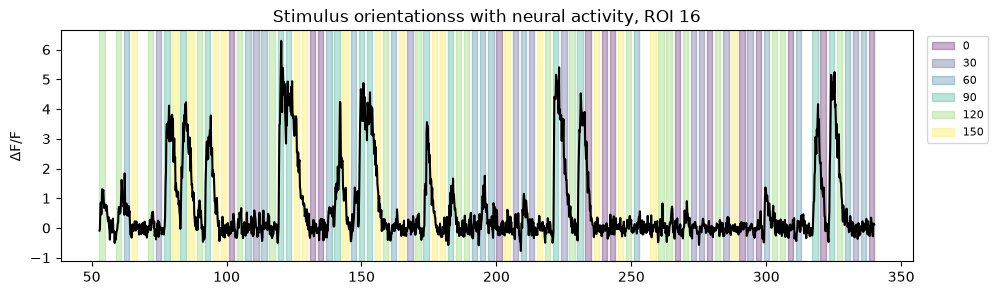

In [32]:
# Replot for orientations

presentations = presentations.dropna(subset=['direction'])
presentations['orientation'] = (presentations['direction'].round().astype(int) % 180)
orientations = sorted(presentations.orientation.dropna().unique())
colors3 = dict(zip(orientations, plt.colormaps['viridis'].resampled(len(orientations)).colors))

def shade_stimulus_orientation(ax):
    for orientation in orientations:
        stim = presentations[presentations.orientation == orientation]

        for i, (start, stop) in enumerate(zip(stim.start_time, stim.stop_time)):
            ax.axvspan(start, stop,
                       color=colors3[orientation],
                       alpha=0.3,
                       label=orientation if i == 0 else None)   # label only the first

# Plot neural activity 
fig, ax = plt.subplots(1, 1, figsize=(11, 3), sharex=True)

starts = epochs[epochs.stim_name == 'drifting_gratings_full'].start_time
stops = epochs[epochs.stim_name == 'drifting_gratings_full'].stop_time
inds = np.where((ts > starts[0]) & (ts < stops[0]))[0]
ts_sub = ts[inds]
dff_sub = dff[:, ROI][inds]

ax.plot(ts_sub, dff_sub, color='black')
ax.set_ylabel(r'$\Delta$F/F')
ax.set_title(f'Stimulus orientationss with neural activity, ROI {ROI}')  

# Add stimulus shading 
shade_stimulus_orientation(ax)
# Gaps are NaNs

# Add legend 
ax.legend(bbox_to_anchor=(1.01, 1.0), loc='upper left', fontsize=8)

plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #FFFFD8;">

After collapsing down directions to orientations, the AI proposes to:
```python
# 8c — Polar orientation tuning (mirrored to full 360° circle)
# The 0–180° curve is duplicated at 180–360° to give a symmetric polar display.
```
_Does this make sense?_

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #FFFFD8;">

To calculate the PSTH, it runs:
```python
for i, (_, row) in enumerate(dg_stim.iterrows()):
    onset  = row['start_time']
    t_rel  = timestamps - onset
    in_win = (t_rel >= -pre_win) & (t_rel <= stim_dur + post_win)
    idx    = np.where(in_win)[0]
    print(idx)
    if len(idx) < 2:
        continue
    # Interpolate to common grid so misaligned frames can be averaged across trials
    psth_matrix[i] = np.interp(t_grid, t_rel[idx], roi_dff[idx])
```
Is a 2 point time series a satisfactory minimum for computing a PSTH?

Should we be concerned that when the available time window is different, the "interpolation" is actually an "extrapolation"?

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #FFFFD8;">

How did it deal with missing values e.g., NaN orientations?
```python
dg_stim = dg_stim.dropna(subset=['direction', 'response'])
```
It also prints: "Missing responses : 0 / 192"

_Is this all okay?_

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #FFFFD8;">

[Exercise] Other potential concerns to discuss:

- How are we handling multiple temporal frequencies?
- Times are relative to what (what is zero time?) and what are time units?
- Could the response window perhaps be longer and not necessarily symmetric around the peak given the slow decay of the signal?
- Should we use the same response window across all data based on average behavior rather than individually for each roi? What happens if it tries to find a peak in non-responsive data?
- Should we consider using nwb.processing['plane-0']['neuropil_corrected'] instead?

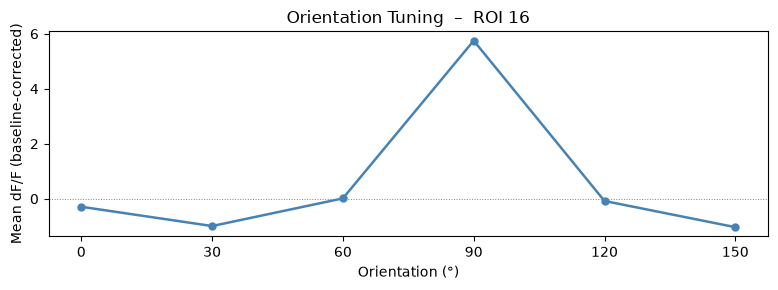

In [13]:
# Simplified code for Step 1

# ── Load data and extract epoch and stimulus tables ─────────────────────────
session_name = '409828_2018-11-06_14-02-59_filtered_2026-04-09_04-59-00'
nwb_filename = '409828_2018-11-06_14-02-59.nwb.zarr'
nwb_path     = str(Path('/data/409828_V1DD_Filtered') / session_name / nwb_filename)

io      = NWBZarrIO(nwb_path, mode='r')
nwbfile = io.read()

epoch_table = nwbfile.intervals['epochs'].to_dataframe()
stim_table  = nwbfile.intervals['stimulus_table'].to_dataframe()

dg_stim = stim_table[stim_table['stim_name'] == 'drifting_gratings_full'].copy()

# ── Load single-ROI dF/F trace ────────────────────────────────────────────
roi = 16
plane = 'plane-3'
dff_obj_sel = nwbfile.processing[plane]['dff']
roi_dff     = np.array(dff_obj_sel.data[:, roi])  # (nframes,)
timestamps  = nwbfile.processing['plane-3']['dff'].timestamps[:]

# ── Compute per-trial responses (window mean minus pre-stim baseline) ──────
resp_start = 0.7
resp_end  = 2.5

trial_responses = []
for _, row in dg_stim.iterrows():
    onset  = row['start_time']
    t_rel  = timestamps - onset

    # 0.5 s pre-stimulus window for baseline estimate
    base_idx = np.where((t_rel >= -0.5) & (t_rel < 0.0))[0]
    baseline = float(np.nanmean(roi_dff[base_idx])) if len(base_idx) > 0 else 0.0

    resp_idx = np.where((t_rel >= resp_start) & (t_rel <= resp_end))[0]
    if len(resp_idx) == 0:
        trial_responses.append(np.nan)
    else:
        trial_responses.append(float(np.nanmean(roi_dff[resp_idx])) - baseline)

dg_stim['response'] = trial_responses

# ── Orientation tuning: collapse direction → orientation (direction % 180)
dg_stim = dg_stim.dropna(subset=['direction', 'response'])
dg_stim['orientation'] = (dg_stim['direction'].round().astype(int) % 180)

tuning = (
    dg_stim.groupby('orientation')['response']
    .mean()    # Just save mean for aggregating across cells
    .reset_index()
)
#print("\nOrientation tuning table:")
#print(tuning.to_string(index=False))

# ── Visualize ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(1,1, figsize=(8, 3))

oris  = tuning['orientation'].values
means = tuning['response'].values
ax.plot(oris, means, 'o-',
             color='steelblue', lw=1.8, ms=5)
ax.axhline(0, color='gray', ls=':', lw=0.7)
ax.set_xticks(oris)
ax.set_xlabel('Orientation (°)')
ax.set_ylabel('Mean dF/F (baseline-corrected)')
ax.set_title(f"Orientation Tuning  –  ROI {best_roi_info['roi_id']}")

plt.tight_layout()
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;">

#### [Prompt]
Next,
- Now please batch this process for all the available roi's and recording sessions, based on the block "Simplified code for Step 1"
- Please report on data completeness and any missing data, as well as what rois are available across which sessions

Output format:
- Please write a code block in the section of this Jupyter notebook after "Step 2: Batch process all data"
- Save any computational output to the /scratch folder


#### Step 2: Batch process all data

In [ ]:
# GENERATED CODE

# === Step 2: Batch orientation tuning across all ROIs and all sessions ===
# Generalizes "Simplified code for Step 1" from one ROI in one session to every
# ROI in every session, and audits data completeness along the way.
#
# Three things had to change from Step 1 to be correct at scale:
#   * Step 1 used `roi = 16` as a COLUMN INDEX into the dF/F matrix. The `roi`
#     field in the ROI table is a separate global identifier -- the one used by
#     coregistration_1196.feather. Both are kept here: `roi_idx` (array column)
#     and `roi` (identifier), alongside column/volume/plane, which together form
#     the key that links back to the EM tables in Step 4.
#   * Sessions are stored in two backends (.nwb.zarr and plain .nwb/HDF5), so we
#     use pynwb.read_nwb(), which dispatches on the file type, rather than
#     NWBZarrIO, which reads only the zarr stores.
#   * Every failure (missing session, plane, stimulus, or trial) is recorded
#     rather than raised, so one bad session cannot abort the batch and the
#     completeness report reflects what actually happened.

import traceback
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import pynwb

warnings.filterwarnings('ignore')

# ── Configuration (same response windows as "Simplified code for Step 1") ─────
DATA_ROOT = Path('/data/409828_V1DD_Filtered')
OUT_DIR   = Path('/scratch/v1dd_step2')
STIM_NAME = 'drifting_gratings_full'
RESP_START, RESP_END = 0.7, 2.5    # s after trial onset
BASE_START, BASE_END = -0.5, 0.0   # s relative to trial onset
DFF_KEY    = 'dff'
MAX_PLANES = 8                     # probe plane-0 .. plane-7; only existing ones are used

OUT_DIR.mkdir(parents=True, exist_ok=True)


def find_nwb_path(session_dir):
    """Return the NWB store inside a session folder (zarr or HDF5), or None."""
    hits = sorted(list(session_dir.glob('*.nwb.zarr')) + list(session_dir.glob('*.nwb')))
    return hits[0] if hits else None


def trial_window_indices(timestamps, onsets, t0, t1):
    """Frame index bounds [lo, hi) covering [onset+t0, onset+t1] for each trial.

    Timestamps are monotonically increasing, so searchsorted is exact and far
    cheaper than the per-trial boolean mask used in Step 1."""
    lo = np.searchsorted(timestamps, onsets + t0, side='left')
    hi = np.searchsorted(timestamps, onsets + t1, side='right')
    return lo, hi


def window_means(dff, lo, hi):
    """Per-trial, per-ROI nanmean of dF/F over frame windows [lo, hi).

    Returns (n_trials, n_rois); NaN where a trial had no frames or only NaNs."""
    out = np.full((len(lo), dff.shape[1]), np.nan)
    for i in range(len(lo)):
        if hi[i] > lo[i]:
            seg = dff[lo[i]:hi[i]]
            # An all-NaN column stays NaN -- recorded as missing, never as 0
            out[i] = np.nanmean(seg, axis=0) if np.isfinite(seg).any() else np.nan
    return out


# ── Main loop over sessions ───────────────────────────────────────────────────
session_dirs = sorted([d for d in DATA_ROOT.iterdir() if d.is_dir()])
print(f"Found {len(session_dirs)} session folders under {DATA_ROOT}\n")

session_rows, roi_rows, tuning_rows, issues = [], [], [], []

for s_i, session_dir in enumerate(session_dirs):
    session_name = session_dir.name
    rec = dict(session_name=session_name)
    print(f"[{s_i + 1:2d}/{len(session_dirs)}] {session_name}")

    nwb_path = find_nwb_path(session_dir)
    if nwb_path is None:
        rec.update(status='no_nwb_file', n_planes=0, n_rois=0, n_dg_trials=0)
        session_rows.append(rec)
        issues.append(f"{session_name}: no .nwb or .nwb.zarr found")
        print("    !! no NWB file")
        continue

    rec['nwb_file'] = nwb_path.name
    rec['backend']  = 'zarr' if nwb_path.name.endswith('.zarr') else 'hdf5'

    try:
        nwb = pynwb.read_nwb(str(nwb_path))
    except Exception as e:
        rec.update(status=f'read_failed: {e}', n_planes=0, n_rois=0, n_dg_trials=0)
        session_rows.append(rec)
        issues.append(f"{session_name}: read_nwb failed -- {e}")
        print(f"    !! read failed: {e}")
        continue

    rec['session_id'] = getattr(nwb, 'session_id', None)

    # ── Stimulus / epoch tables ───────────────────────────────────────────────
    if 'stimulus_table' not in nwb.intervals:
        rec.update(status='no_stimulus_table', n_planes=0, n_rois=0, n_dg_trials=0)
        session_rows.append(rec)
        issues.append(f"{session_name}: no stimulus_table")
        continue

    stim_table  = nwb.intervals['stimulus_table'].to_dataframe()
    epoch_table = (nwb.intervals['epochs'].to_dataframe()
                   if 'epochs' in nwb.intervals else pd.DataFrame())
    rec['stim_names_present'] = ';'.join(sorted(stim_table['stim_name'].dropna().unique()))
    rec['n_epochs'] = len(epoch_table)

    dg = stim_table[stim_table['stim_name'] == STIM_NAME].copy()
    rec['n_dg_trials'] = len(dg)
    if len(dg) == 0:
        rec.update(status=f'no_{STIM_NAME}', n_planes=0, n_rois=0)
        session_rows.append(rec)
        issues.append(f"{session_name}: stimulus '{STIM_NAME}' absent "
                      f"(present: {rec['stim_names_present']})")
        print(f"    !! no {STIM_NAME}")
        continue

    # Trials with no direction cannot contribute to an orientation curve
    rec['n_dg_trials_missing_direction'] = int(dg['direction'].isna().sum())
    dg = dg.dropna(subset=['direction'])
    dg['orientation'] = dg['direction'].round().astype(int) % 180

    rec['directions']           = ';'.join(str(x) for x in sorted(dg['direction'].unique()))
    rec['n_orientations']       = dg['orientation'].nunique()
    rec['temporal_frequencies'] = ';'.join(str(x) for x in sorted(dg['temporal_frequency'].dropna().unique()))
    rec['spatial_frequencies']  = ';'.join(str(x) for x in sorted(dg['spatial_frequency'].dropna().unique()))
    rec['n_dg_trials_used']     = len(dg)
    rec['dg_trial_duration_s']  = float((dg['stop_time'] - dg['start_time']).median())
    rec['dg_epoch_count']       = int((epoch_table['stim_name'] == STIM_NAME).sum()) if len(epoch_table) else np.nan

    onsets       = dg['start_time'].to_numpy(float)
    orientations = dg['orientation'].to_numpy(int)
    uniq_ori     = np.unique(orientations)

    # ── Per-plane processing ──────────────────────────────────────────────────
    plane_names = [f'plane-{i}' for i in range(MAX_PLANES) if f'plane-{i}' in nwb.processing]
    rec['planes_present'] = ';'.join(plane_names)
    rec['n_planes'] = len(plane_names)
    if not plane_names:
        issues.append(f"{session_name}: no plane-* processing modules")

    n_rois_session = 0
    for plane_name in plane_names:
        try:
            module = nwb.processing[plane_name]
            if DFF_KEY not in module.data_interfaces:
                issues.append(f"{session_name}/{plane_name}: no '{DFF_KEY}' interface "
                              f"(has: {sorted(module.data_interfaces)})")
                continue

            dff_obj    = module[DFF_KEY]
            timestamps = np.asarray(dff_obj.timestamps[:], dtype=float)
            dff        = np.asarray(dff_obj.data[:], dtype=float)   # (n_frames, n_rois)
            roi_tbl    = dff_obj.rois.to_dataframe().reset_index(drop=True)

            # Shape sanity: a mismatch means the ROI mapping is not trustworthy
            if dff.shape[0] != len(timestamps):
                issues.append(f"{session_name}/{plane_name}: dff frames {dff.shape[0]} != "
                              f"timestamps {len(timestamps)} -- truncating to the shorter")
                n = min(dff.shape[0], len(timestamps))
                dff, timestamps = dff[:n], timestamps[:n]
            if dff.shape[1] != len(roi_tbl):
                issues.append(f"{session_name}/{plane_name}: dff columns {dff.shape[1]} != "
                              f"ROI table rows {len(roi_tbl)} -- SKIPPED (ambiguous ROI mapping)")
                continue

            # Trials falling outside this plane's recorded time range are unusable
            n_out = int(((onsets + RESP_START) > timestamps[-1]).sum()
                        + ((onsets + RESP_END) < timestamps[0]).sum())
            if n_out:
                issues.append(f"{session_name}/{plane_name}: {n_out} {STIM_NAME} trials "
                              f"outside the dF/F time range")

            # ── Per-trial responses: window mean minus pre-stimulus baseline ──
            r_lo, r_hi = trial_window_indices(timestamps, onsets, RESP_START, RESP_END)
            b_lo, b_hi = trial_window_indices(timestamps, onsets, BASE_START, BASE_END)
            resp = window_means(dff, r_lo, r_hi)      # (n_trials, n_rois)
            base = window_means(dff, b_lo, b_hi)
            # Step 1 substituted baseline = 0 when the pre-stimulus window was
            # empty; the same convention is kept so batch and single-ROI agree
            base = np.nan_to_num(base, nan=0.0)
            trial_resp = resp - base

            # ── Orientation tuning: mean / SEM / n over trials per orientation ─
            n_rois = trial_resp.shape[1]
            for ori in uniq_ori:
                sel  = trial_resp[orientations == ori]              # (n_repeats, n_rois)
                n_ok = np.isfinite(sel).sum(axis=0)
                with np.errstate(invalid='ignore'):
                    mean = np.nanmean(sel, axis=0)
                    sd   = np.nanstd(sel, axis=0, ddof=1)
                sem = np.where(n_ok > 1, sd / np.sqrt(np.maximum(n_ok, 1)), np.nan)
                tuning_rows.append(pd.DataFrame(dict(
                    session_name  = session_name,
                    column        = roi_tbl['column'].astype(str).values,
                    volume        = roi_tbl['volume'].astype(str).values,
                    plane         = roi_tbl['plane'].values,
                    roi           = roi_tbl['roi'].values,
                    roi_idx       = np.arange(n_rois),
                    orientation   = int(ori),
                    mean_response = mean,
                    sem           = sem,
                    n_trials      = n_ok,
                )))

            # ── Per-ROI completeness bookkeeping ──────────────────────────────
            n_valid = np.isfinite(trial_resp).sum(axis=0)
            roi_rows.append(pd.DataFrame(dict(
                session_name   = session_name,
                plane_name     = plane_name,
                column         = roi_tbl['column'].astype(str).values,
                volume         = roi_tbl['volume'].astype(str).values,
                plane          = roi_tbl['plane'].values,
                roi            = roi_tbl['roi'].values,
                roi_idx        = np.arange(n_rois),
                is_soma        = (roi_tbl['is_soma'].values if 'is_soma' in roi_tbl else np.nan),
                n_frames       = dff.shape[0],
                frac_nan_dff   = np.isnan(dff).mean(axis=0),
                n_trials_total = len(onsets),
                n_trials_valid = n_valid,
                n_orientations = len(uniq_ori),
            )))
            n_rois_session += n_rois
            print(f"    {plane_name}: {n_rois:4d} ROIs, "
                  f"{n_valid.min():3d}-{n_valid.max():3d} valid trials/ROI")

            del dff, resp, base, trial_resp

        except Exception as e:
            issues.append(f"{session_name}/{plane_name}: EXCEPTION {e}\n{traceback.format_exc(limit=3)}")
            print(f"    !! {plane_name}: {e}")

    rec['n_rois'] = n_rois_session
    rec['status'] = 'ok' if n_rois_session > 0 else 'no_rois_processed'
    session_rows.append(rec)

# ── Assemble and persist outputs ──────────────────────────────────────────────
sessions_df = pd.DataFrame(session_rows)
rois_df     = pd.concat(roi_rows,    ignore_index=True) if roi_rows    else pd.DataFrame()
tuning_df   = pd.concat(tuning_rows, ignore_index=True) if tuning_rows else pd.DataFrame()

# Wide tuning table: one row per ROI, one column per orientation (input to Step 3)
if len(tuning_df):
    key = ['session_name', 'column', 'volume', 'plane', 'roi', 'roi_idx']
    tuning_wide = (tuning_df.pivot_table(index=key, columns='orientation',
                                         values='mean_response', dropna=False)
                            .reset_index())
    tuning_wide.columns = [c if isinstance(c, str) else f'ori_{c}' for c in tuning_wide.columns]
else:
    tuning_wide = pd.DataFrame()

sessions_df.to_csv(OUT_DIR / 'session_inventory.csv', index=False)
rois_df.to_parquet(OUT_DIR / 'roi_inventory.parquet', index=False)
tuning_df.to_parquet(OUT_DIR / 'tuning_curves_long.parquet', index=False)
tuning_wide.to_parquet(OUT_DIR / 'tuning_curves_wide.parquet', index=False)
(OUT_DIR / 'issues_log.txt').write_text('\n'.join(issues) if issues else '(none)\n')

# ── Completeness report ───────────────────────────────────────────────────────
lines = []
add = lines.append
add('=' * 78)
add('STEP 2 BATCH -- DATA COMPLETENESS REPORT')
add('=' * 78)
add(f"Session folders found        : {len(sessions_df)}")
add(f"Sessions processed OK        : {(sessions_df['status'] == 'ok').sum()}")
bad = sessions_df[sessions_df['status'] != 'ok']
add(f"Sessions NOT processed       : {len(bad)}")
for _, r in bad.iterrows():
    add(f"    - {r['session_name']}: {r['status']}")
add('')
add(f"Storage backends             : {sessions_df['backend'].value_counts().to_dict()}")
add(f"Total ROIs with tuning curves: {len(rois_df)}")
if len(rois_df):
    add(f"Distinct (col,vol,plane,roi) : {rois_df[['column','volume','plane','roi']].drop_duplicates().shape[0]}")
    add(f"is_soma == True              : {int((rois_df['is_soma'] == True).sum())} / {len(rois_df)}")
    add(f"ROIs with any NaN in dF/F    : {int((rois_df['frac_nan_dff'] > 0).sum())}")
    add(f"ROIs missing >=1 trial       : {int((rois_df['n_trials_valid'] < rois_df['n_trials_total']).sum())}")
    add(f"ROIs with zero valid trials  : {int((rois_df['n_trials_valid'] == 0).sum())}")
add('')
add('-' * 78)
add('PER-SESSION INVENTORY')
add('-' * 78)
add(sessions_df.reindex(columns=['session_name', 'backend', 'n_planes', 'n_rois',
                                 'n_dg_trials', 'n_dg_trials_used', 'n_orientations',
                                 'status']).to_string(index=False))
add('')
add('-' * 78)
add('ROI AVAILABILITY ACROSS SESSIONS')
add('-' * 78)
if len(rois_df):
    per_key = (rois_df.groupby(['column', 'volume', 'plane', 'roi'])['session_name']
                      .nunique().rename('n_sessions').reset_index())
    add(f"Distinct ROI keys (column,volume,plane,roi): {len(per_key)}")
    add('Number of sessions each ROI key appears in:')
    add(per_key['n_sessions'].value_counts().sort_index().to_string())
    add('')
    add('ROI counts by (column, volume) x session:')
    add(rois_df.groupby(['column', 'volume', 'session_name'])['roi']
               .nunique().rename('n_rois').reset_index().to_string(index=False))
add('')
add(f"Anomalies logged: {len(issues)}  (full text in {OUT_DIR / 'issues_log.txt'})")
for line in issues[:40]:
    add(f"    - {line.splitlines()[0]}")

report = '\n'.join(lines)
(OUT_DIR / 'completeness_report.txt').write_text(report)
print('\n' + report)
print(f"\nSaved outputs to {OUT_DIR}")


Its response to me:

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #DDEDE4;">

It first tried to write a new notebook, so I asked it again to write it in the existing notebook. 

It then ran its own verification code, noting that "Batch is running and producing sensible per-plane counts. While it works, let me prepare the cross-check against Step 1's ROI."

It then pointed out:

1. Step 1's roi = 16 is an array index, not the roi identifier. The ROI table has columns column, volume, plane, roi, and roi is a sparse global id (plane-3 has 165 ROIs with roi values ranging 0–516). Those four fields together are exactly the key in coregistration_1196.feather. The batch carries both roi_idx and roi so Step 4's merge can't silently join on the wrong one.

2. Two of the 25 sessions are HDF5 .nwb, not .nwb.zarr (409828_2018-11-20_12-12-08, 409828_2018-12-07_15-05-38). NWBZarrIO as used in Step 1 would fail on those; the batch uses pynwb.read_nwb(), which dispatches on file type.

    Also visible in the running log: session 1 reports 184 valid trials/ROI, while Step 1 printed "Missing responses: 0 / 192" — the 8-trial gap is drifting_gratings_full rows with NaN direction (blank/grey sweeps), which Step 1 dropped after printing its completeness line. The batch counts them explicitly as n_dg_trials_missing_direction.

The session then ran out of memory during the run. It diagnosed itself for an issue during assembly, after computing all 25 sessions: "pivot_table(dropna=False) builds the cartesian product of all six index levels — 16 rows from an 8-row toy. At real scale (25 sessions × ~1500 distinct roi × 500 roi_idx × 6 planes) that's hundreds of millions of rows. Fixing the cell."

#### [Prompt]

Next, 
- Compute tuning width from tuning curves
- Compute orientation selectivity index (OSI)
- Consult https://github.com/AllenInstitute/v1dd_physiology
- Create a scatterplot comparing tuning width and OSI across samples

Output format:
- Please write a code block in the section of this Jupyter notebook after "Step 3: Compute tuning metrics"
- Start accumulating tuning curve and tuning metrics into a dataframe organized by "roi" identifier.

#### Step 3: Compute tuning metrics

Verification:
Do the two metrics roughly agree with each other?
Pick a cell with a high and low tuning width and visualize if the tuning curves make sense

#### [Prompt]
Next,
- Merge this with the cell type and connectivity information
- Plot tuning curves for each cell type - include individual (thin traces) and average (thick trace)
- Compute mean tuning widths / OSI for each cell type

Output format:
- Please write a code block in the section of this Jupyter notebook after "Step 4: Coregisteration with EM data and examination of tuning as a function of cell type"

#### Step 4: Coregisteration with EM data and examination of tuning as a function of cell type

In [ ]:
path = '/data/v1dd_1196/'
df_coreg = pd.read_feather(os.path.join(path, 'coregistration_1196.feather'))
df_coreg
# Compare roi lists

In [ ]:
df_ct = pd.read_feather(os.path.join(path, 'soma_and_cell_type_1196.feather'))
print(df_ct['cell_type'].value_counts())
df_ct
# Check against coreg list

Verification:

- Did it merge correctly?
    - What column did it merge on?
    - Did it do an inner, left, right, outer join, etc.?
    - What were dimensions before and after merge?
    - How does it handle cells being in multiple sessions?
    - What does the resulting table look like?
    - What are unique values in the important columns?

- Do the tuning curves for each cell type look right?
    - How is averaging? in the averaging table can you include a cell type column? 
    - Did it normalize?
    - Did it aligned the curves to peak?

- Do the tuning curves look as they would expect for various cell types and are there any differences?
- Do the tuning metrics across cell types agree with the tuning curves across cell types?

#### [Prompt]
Can we also run a slightly different analysis:
- After normalizing for euclidean distance (see trusting_connectivity_code_workshop.ipynb), what is the relationship between tuning similarity and connection probability?
- Create some visualizations of this relationship

Output format:
- Please write a code block in the section of this Jupyter notebook after "Step 5: Analyze tuning similarity versus connection probability"

#### Step 5: Analyze tuning similarity versus connection probability

Verification

-How is it quantifying tuning similarity - e.g., centroid or peak?


### Bonus extension exercise [Option A]:
Work with an LLM to look at diversity of tuning of presynaptic units synapsing onto individual pyramidal neurons and the relationship of that to the tuning of the postsynaptic neuron. Create a visualization and quantify. Verify this code. 

Reference paper on salt and pepper organization in mouse.

### Bonus extension exercise [Option B]:
Work with an LLM to look at sparsity of responses to natural stimuli. You can start with a simple metric like kurtosis and build up to a more complex metric of choice. You could examine lifetime sparseness of each neuron as well as population sparseness in subsets of neurons. For instance, does this vary with cell depth (e.g., input layers versus supragranular versus infragranular)? Verify the generated code.

## Food for Thought (Literature extensions)


[Spatial Clustering of Tuning in Mouse Primary Visual Cortex](https://www.nature.com/articles/ncomms12270)

[Orientation and direction tuning align with dendritic morphology and spatial connectivity in mouse visual cortex](https://www.sciencedirect.com/science/article/pii/S0960982222002810)

[Response Selectivity Is Correlated to Dendritic Structure in Parvalbumin-Expressing Inhibitory Neurons in Visual Cortex](https://www.jneurosci.org/content/33/28/11724)